# Setup

In [1]:
%pip install -qU wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 62.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## W&B Login

In [2]:
#@title W&B login
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
wandb.login(user_secrets.get_secret("W&B-mnist-simpleCNN-countergan"));

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rajveerjadhav08 (rajveerjadhav08-maas) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Imports

In [3]:
#@title Imports
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt 
from itertools import cycle

## W&B Init-Config

In [4]:
wandb.init(
    project="mnist-simplecnn",
    config={
        "epochs": 5,
        "batch_size": 64,
        "lr_cnn": 1e-3,
        "lr_gan": 2e-4,
        "betas":(0.5, 0.999),
        "seed": 42
    }
)
config = wandb.config

wandb: setting up run hf6myckp
wandb: Tracking run with wandb version 0.26.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260416_143002-hf6myckp
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run still-eon-10
wandb: ⭐️ View project at https://wandb.ai/rajveerjadhav08-maas/mnist-simplecnn
wandb: 🚀 View run at https://wandb.ai/rajveerjadhav08-maas/mnist-simplecnn/runs/hf6myckp


## Reproducibility

In [5]:
#@title Reproducibility
random.seed(config.seed)
np.random.seed(config.seed)
torch.manual_seed(config.seed)
torch.cuda.manual_seed(config.seed)
torch.cuda.manual_seed_all(config.seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False # to find the best GPU algo for optimization
torch.use_deterministic_algorithms(True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Data Loading

In [6]:
#@title Data
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="/kaggle/working/", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="/kaggle/working/", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=config.batch_size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.63MB/s]


# Model Architecture

In [7]:
#@title Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))     
        x = F.relu(self.conv2(x))     
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [8]:
model = SimpleCNN().to(device)

## Configure HyperParams

In [9]:
#@title HyperParams
optimizer = optim.Adam(model.parameters(), lr=config.lr_cnn)
criterion = nn.CrossEntropyLoss()

# Train-Eval

In [10]:
best_accuracy = 0.0

for epoch in range(config.epochs):
    start_time = time.time()

    # --- TRAIN ---
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # --- EVAL ---
    model.eval()
    correct = 0
    total = 0
    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_loss /= len(test_loader)
    accuracy = correct / total

    # --- TIME ---
    epoch_time = time.time() - start_time

    # --- SAVE ---
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        checkpoint_path = "best-mnist-cnn.pt"
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "accuracy": accuracy,
        }, checkpoint_path)

    # --- LOG W&B ---
    wandb.log({
        "train_loss": train_loss,
        "test_loss": test_loss,
        "accuracy": accuracy,
        "epoch_time_sec": epoch_time
    })

    print(f"loss={train_loss:.4f}, acc={accuracy:.4f}, time={epoch_time:.2f}s")

# --- CKPTH ARTIFACT W&B ---
artifact = wandb.Artifact(
            name="best-mnist-cnn",
            type="model",
            metadata={"accuracy": accuracy}
        )
artifact.add_file(checkpoint_path)
wandb.log_artifact(artifact)

loss=0.1564, acc=0.9855, time=13.10s
loss=0.0443, acc=0.9864, time=11.65s
loss=0.0290, acc=0.9891, time=11.75s
loss=0.0201, acc=0.9865, time=11.69s
loss=0.0145, acc=0.9859, time=11.65s


<Artifact best-mnist-cnn>

## SimpleCNN Visualization

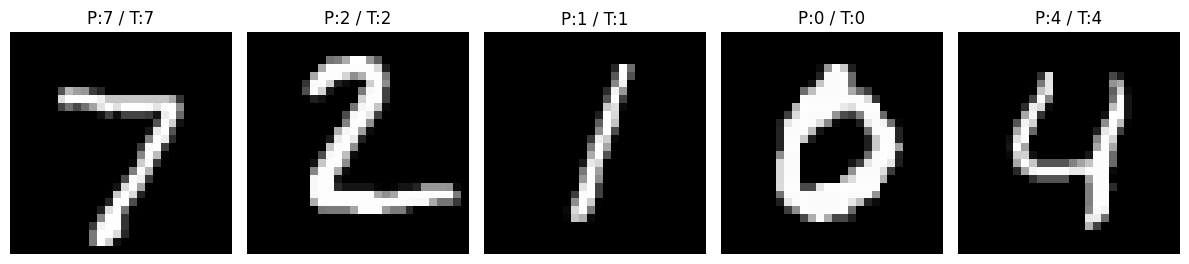

In [11]:
model.eval()
images, labels = next(iter(test_loader))

images = images[:5].to(device)
labels = labels[:5].to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

# Plot
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"P:{preds[i].item()} / T:{labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
wandb.log({
    "predictions": [
        wandb.Image(images[i], caption=f"P:{preds[i].item()} T:{labels[i].item()}")
        for i in range(5)
    ]
})

# Cycle GAN

## Residual Block

In [13]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, 1, 1)
        self.conv2 = nn.Conv2d(channels, channels, 3, 1, 1)

    def forward(self, x):
        return x + self.conv2(F.relu(self.conv1(x)))

## Generator

In [14]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 7, 1, 3),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(),

            ResBlock(128),
            ResBlock(128),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(64, 1, 7, 1, 3),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

## Discriminator

In [15]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 1, 3, 1, 1)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
G_A = Generator().to(device) # 7 -> 1 
G_B = Generator().to(device) # 1 -> 7

D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

In [17]:
g_optimizer = torch.optim.Adam(
    list(G_A.parameters()) + list(G_B.parameters()),
    lr=config.lr_gan,
    betas=config.betas
)

d_A_optimizer = torch.optim.Adam(D_A.parameters(), lr=config.lr_gan, betas=config.betas)
d_B_optimizer = torch.optim.Adam(D_B.parameters(), lr=config.lr_gan, betas=config.betas)

In [18]:
def adv_loss(pred, target):
    return torch.mean((pred - target) ** 2)  # LSGAN

def cycle_loss(real, reconstructed):
    return torch.mean(torch.abs(real - reconstructed))

def identity_loss(real, same):
    return torch.mean(torch.abs(real - same))

In [19]:
idx_A = [i for i, (_, label) in enumerate(train_dataset) if label == 7]
idx_B = [i for i, (_, label) in enumerate(train_dataset) if label == 1]

dataset_A = Subset(train_dataset, idx_A)
dataset_B = Subset(train_dataset, idx_B)

batch_size = 64

loader_A = DataLoader(dataset_A, batch_size=config.batch_size, shuffle=True, drop_last=True)
loader_B = DataLoader(dataset_B, batch_size=config.batch_size, shuffle=True, drop_last=True)

wandb: WARNING Artifact "best-mnist-cnn" already exists with the same content. No new version will be created.


In [20]:
lambda_cycle = 10
lambda_id = 5

for epoch in range(20):
    for real_A_batch, real_B_batch in zip(loader_A, cycle(loader_B)):

        real_A, _ = real_A_batch
        real_B, _ = real_B_batch

        real_A = real_A.to(device)
        real_B = real_B.to(device)

        # ======================
        # Train Generators
        # ======================
        fake_B = G_B(real_A)
        fake_A = G_A(real_B)
        
        cycle_A = G_A(fake_B)
        cycle_B = G_B(fake_A)
        
        id_A = G_A(real_A)
        id_B = G_B(real_B)

        loss_G = (
            adv_loss(D_B(fake_B), 1) +
            adv_loss(D_A(fake_A), 1) +
            lambda_cycle * (cycle_loss(real_A, cycle_A) + cycle_loss(real_B, cycle_B)) +
            lambda_id * (identity_loss(real_A, id_A) + identity_loss(real_B, id_B))
        )

        g_optimizer.zero_grad()
        loss_G.backward()
        g_optimizer.step()

        # ======================
        # Train D_A
        # ======================
        loss_D_A = (
            adv_loss(D_A(real_A), 1) +
            adv_loss(D_A(fake_A.detach()), 0)
        )

        d_A_optimizer.zero_grad()
        loss_D_A.backward()
        d_A_optimizer.step()

        # ======================
        # Train D_B
        # ======================
        loss_D_B = (
            adv_loss(D_B(real_B), 1) +
            adv_loss(D_B(fake_B.detach()), 0)
        )

        d_B_optimizer.zero_grad()
        loss_D_B.backward()
        d_B_optimizer.step()
        
    # === END OF EPOCH LOOP ===
    wandb.log({
        "loss_G": loss_G.item(),
        "loss_D_A": loss_D_A.item(),
        "loss_D_B": loss_D_B.item(),
        "cycle_loss": (cycle_loss(real_A, cycle_A) + cycle_loss(real_B, cycle_B)).item(),
        "id_loss": (identity_loss(real_A, id_A) + identity_loss(real_B, id_B)).item(),
        "epoch": epoch
    })
    
    if epoch % 2 == 0:
        wandb.log({
            "real_A": [wandb.Image(real_A[i].cpu(), caption="7") for i in range(3)],
            "fake_B": [wandb.Image(fake_B[i].cpu(), caption="7 to 1") for i in range(3)],
            "cycle_A": [wandb.Image(cycle_A[i].cpu(), caption="cycle") for i in range(3)],
        })
        
    print(f"Epoch {epoch}: G={loss_G:.3f}, D_A={loss_D_A:.3f}, D_B={loss_D_B:.3f}")

wandb: WARNING Data passed to `wandb.Image` should consist of values in the range [0, 255], image data will be normalized to this range, but behavior will be removed in a future version of wandb.


Epoch 0: G=1.751, D_A=0.343, D_B=0.419
Epoch 1: G=1.555, D_A=0.321, D_B=0.358
Epoch 2: G=1.604, D_A=0.317, D_B=0.339
Epoch 3: G=1.318, D_A=0.412, D_B=0.428
Epoch 4: G=1.594, D_A=0.416, D_B=0.476
Epoch 5: G=1.379, D_A=0.454, D_B=0.438
Epoch 6: G=1.292, D_A=0.399, D_B=0.445
Epoch 7: G=1.278, D_A=0.409, D_B=0.424
Epoch 8: G=1.044, D_A=0.427, D_B=0.414
Epoch 9: G=1.116, D_A=0.435, D_B=0.424
Epoch 10: G=1.066, D_A=0.415, D_B=0.433
Epoch 11: G=1.178, D_A=0.392, D_B=0.399
Epoch 12: G=1.239, D_A=0.399, D_B=0.411
Epoch 13: G=1.055, D_A=0.404, D_B=0.390
Epoch 14: G=1.196, D_A=0.389, D_B=0.401
Epoch 15: G=1.279, D_A=0.375, D_B=0.392
Epoch 16: G=1.169, D_A=0.395, D_B=0.389
Epoch 17: G=0.955, D_A=0.385, D_B=0.407
Epoch 18: G=1.125, D_A=0.381, D_B=0.399
Epoch 19: G=1.171, D_A=0.401, D_B=0.413


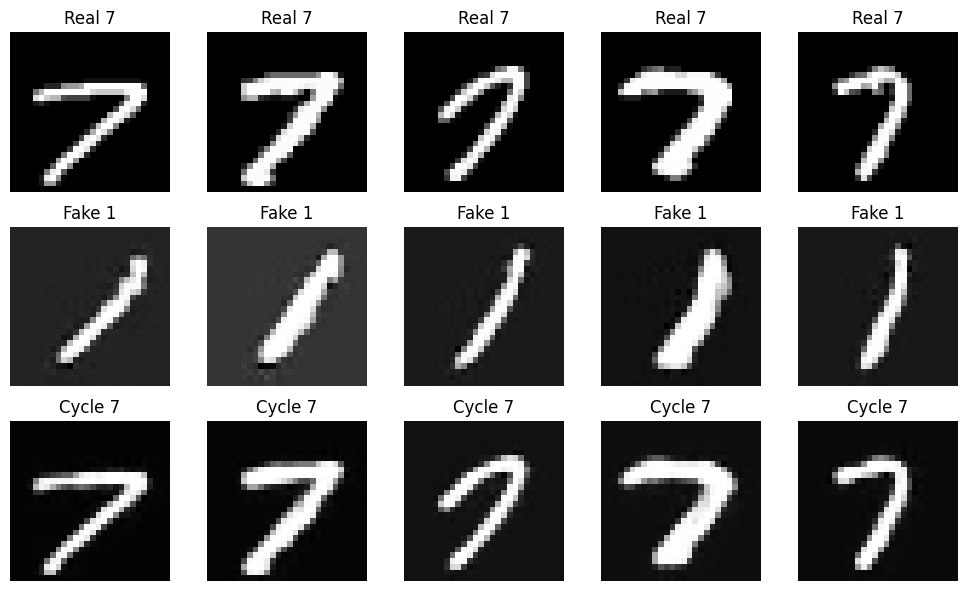

In [21]:
G_A.eval()
G_B.eval()

# Get a batch of 7s
real_A, _ = next(iter(loader_A))
real_A = real_A[:5].to(device)

with torch.no_grad():
    fake_B = G_B(real_A)       # 7 -> 1
    cycle_A = G_A(fake_B)      # back to 7

# Move to CPU
real_A = real_A.cpu()
fake_B = fake_B.cpu()
cycle_A = cycle_A.cpu()

fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i in range(5):
    axes[0, i].imshow(real_A[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Real 7")
    axes[0, i].axis("off")

    axes[1, i].imshow(fake_B[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Fake 1")
    axes[1, i].axis("off")

    axes[2, i].imshow(cycle_A[i].squeeze(), cmap="gray")
    axes[2, i].set_title("Cycle 7")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

In [22]:
wandb.log({
    "cycleGAN_grid": wandb.Image(fig)
})

In [23]:
%pip freeze > requirements.txt
wandb.save("requirements.txt")
wandb.finish()

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Note: you may need to restart the kernel to use updated packages.


wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:       accuracy ▁▃█▃▂
wandb:     cycle_loss █▄▄▄▆▃▃▃▂▂▃▂▂▂▂▂▂▁▂▂
wandb:          epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: epoch_time_sec █▁▁▁▁
wandb:        id_loss █▇▅▆▆▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁
wandb:       loss_D_A ▂▁▁▆▆█▅▆▇▇▆▅▅▅▅▄▅▄▄▅
wandb:       loss_D_B ▅▂▁▆█▆▆▅▅▅▆▄▅▄▄▄▄▄▄▅
wandb:         loss_G █▆▇▄▇▅▄▄▂▂▂▃▄▂▃▄▃▁▂▃
wandb:      test_loss ▇▅▁▅█
wandb:     train_loss █▂▂▁▁
wandb: 
wandb: Run summary:
wandb:       accuracy 0.9859
wandb:     cycle_loss 0.02954
wandb:          epoch 19
wandb: epoch_time_sec 11.64908
wandb:        id_loss 0.01964
wandb:       loss_D_A 0.40052
wandb:       loss_D_B 0.41251
wandb:         loss_G 1.17055
wandb:      test_loss 0.04803
wandb:     train_loss 0.01445
wandb: 
wandb: 🚀 View run still-eon-10 at: https://wandb.ai/rajveerjadhav08-maas/mnist-simplecnn/runs/hf6myckp
wandb: ⭐️ View project at: https://wandb.ai/rajveerjadhav08-maas/mnist-simplecnn
wandb: Synced 4 W&B file(s), 96 media file(s), 0 artifact 